In [1]:
# Importantes imports
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.axes._axes import Axes
import torch
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns
from sklearn.datasets import make_moons, make_circles

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Important Basic Functions
class Sampleable(ABC):
    """
    Distribution which can be sample from
    """
    @property
    @abstractmethod
    def dim(self) -> int:
        """
        Returns:
            -Dimensionality of the distribution
        """
        pass

    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            -num_samples : the desired number of samples
        Return:
            -samples: shape = (bs, dim)
        """
        pass


class Density(ABC):
    """
    Distribution with tractable density
    """
    @abstractmethod
    def log_density(self, x: torch.Tensor) -> torch.Tensor:
        """
        - Returns the log density at x
        Args:
            -x: shape = (bs, dim)
        Returns:
            -log_density: shape=(bs, 1)
        """
        pass


class Gaussian(torch.nn.Module, Sampleable, Density):
    """
    - Multivariate Gaussian distribution
    """
    def __init__(self, mean: torch.Tensor, cov: torch.Tensor):
        """
        mean : shape=(dim, )
        cov: shape=(dim, dim)
        """
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("cov", cov)

    @property
    def dim(self) -> int:
        return self.mean.shape[0]

    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples: int) -> torch.Tensor:
        return self.distribution.sample((num_samples, ))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)

    @classmethod
    def isotropic(cls, dim: int, std: float) -> "Gaussian":
        mean = torch.zeros(dim)
        cov = torch.eye(dim) * std **2
        return cls(mean, cov)

class GaussianMixture(torch.nn.Module, Sampleable, Density):
    """
    2D Mixture Gaussian model (Density and Sampleable). Wraper around torch.distributions.MixtureSameFamily.
    """
    def __init__(self,
                 means: torch.Tensor, # nmodes x data_dim
                 covs: torch.Tensor, # nmodes x data_dim x data_dim
                 weights: torch.Tensor # nmodes
                ):
        """
        means: shape=(nmodes, 2)
        covs: shape=(nmodes, 2, 2)
        weights: shape=(nmodes, 1)
        """
        super().__init__()
        self.nmodes = means.shape[0]
        self.register_buffer("means", means) 
        self.register_buffer("covs", covs) 
        self.register_buffer("weights", weights) 


    @property
    def dim(self) -> int:
        return self.means.shape[1]

    @property
    def distribution(self):
        return D.MixtureSameFamily(
            mixture_distribution=D.Categorical(probs=self.weights, validate_args=False),
            component_distribution=D.MultivariateNormal(
                loc=self.means,
                covariance_matrix=self.covs,
                validate_args=False
            ),
            validate_args=False,
        )

    def log_density(self, x: torch.Tensor) -> torch.Tensor:
        return self.distribution.log_prob(x).view(-1, 1)

    def sample(self, num_samples: int) -> torch.Tensor:
        return self.distribution.sample(torch.Size((num_samples,)))


    @classmethod
    def random_2D(
        cls, nmodes: int, std: float, scale: float = 10.0, x_offset: float=0.0, seed=0.0
    ) -> "GaussianMixture":
        torch.manual_seed(seed)
        means = (torch.rand(nmodes, 2) - 0.5) * scale + x_offset * torch.Tensor([1.0, 0.0])
        covs = torch.diag_embed(torch.ones(nmodes, 2)) * std**2
        weights = torch.ones(nmodes)
        return cls(means, covs, weights)

    @classmethod
    def symmetric_2D(
        cls, nmodes: int, std: float, scale: float=10.0, x_offset: float=0.0
    ) -> "GaussianMixture":
        angles = torch.linspace(0, 2*np.pi, nmodes + 1)[: nmodes]
        means = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1) * scale + torch.Tensor([1.0, 0.0]) * x_offset
        covs = torch.diag_embed(torch.ones(nmodes, 2) * std **2)
        weights = torch.ones(nmodes) / nmodes
        return cls(means, covs, weights)

In [3]:
# Several plotting utility functions
def hist2d_samples(samples, ax: Optional[Axes] = None, bins: int = 200, scale: float = 5.0, percentile: int = 99, **kwargs):
    H, xedges, yedges = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, range=[[-scale, scale], [-scale, scale]])
    
    # Determine color normalization based on the 99th percentile
    cmax = np.percentile(H, percentile)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin) 
    
    # Plot using imshow for more control
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    ax.imshow(H.T, extent=extent, origin='lower', norm=norm, **kwargs)

def hist2d_sampleable(sampleable: Sampleable, num_samples: int, ax: Optional[Axes] = None, bins=200, scale: float = 5.0, percentile: int = 99, **kwargs):
    assert sampleable.dim == 2
    if ax is None:
        ax = plt.gca()
    samples = sampleable.sample(num_samples).detach().cpu() # (ns, 2)
    hist2d_samples(samples, ax, bins, scale, percentile, **kwargs)

def scatter_sampleable(sampleable: Sampleable, num_samples: int, ax: Optional[Axes] = None, **kwargs):
    assert sampleable.dim == 2
    if ax is None:
        ax = plt.gca()
    samples = sampleable.sample(num_samples) # (ns, 2)
    ax.scatter(samples[:,0].cpu(), samples[:,1].cpu(), **kwargs)

def kdeplot_sampleable(sampleable: Sampleable, num_samples: int, ax: Optional[Axes] = None, **kwargs):
    assert sampleable.dim == 2
    if ax is None:
        ax = plt.gca()
    samples = sampleable.sample(num_samples) # (ns, 2)
    sns.kdeplot(x=samples[:,0].cpu(), y=samples[:,1].cpu(), ax=ax, **kwargs)

def imshow_density(density: Density, x_bounds: Tuple[float, float], y_bounds: Tuple[float, float], bins: int, ax: Optional[Axes] = None, x_offset: float = 0.0, **kwargs):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    x = torch.linspace(x_min, x_max, bins).to(device) + x_offset
    y = torch.linspace(y_min, y_max, bins).to(device)
    X, Y = torch.meshgrid(x, y)
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)
    density = density.log_density(xy).reshape(bins, bins).T
    im = ax.imshow(density.cpu(), extent=[x_min, x_max, y_min, y_max], origin='lower', **kwargs)

def contour_density(density: Density, bins: int, scale: float, ax: Optional[Axes] = None, x_offset:float = 0.0, **kwargs):
    if ax is None:
        ax = plt.gca()
    x = torch.linspace(-scale + x_offset, scale + x_offset, bins).to(device)
    y = torch.linspace(-scale, scale, bins).to(device)
    X, Y = torch.meshgrid(x, y)
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)
    density = density.log_density(xy).reshape(bins, bins).T
    im = ax.contour(density.cpu(), origin='lower', **kwargs)

In [4]:
class EDO(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna coeficiente de drift de uma EDO
        Args:
            -xt: x no tempo t, shape=(bs, dim)
            -t: tempo, shape=(bs, 1)
        Returns:
        -drift_coefficient: shape(bs, dim)
        """
        pass

class EDE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o coeficiente de drift de uma EDE.
        Args:
            -xt: x no tempo t, shape=(bs, dim)
            -t: tempo, shape=(bs, 1)
        Returns:
            -drift_coefficient: shape=(bs, dim)
        """
        pass


    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o coeficiente de difusão de uma EDE.
        Args:
            -xt: x no tempo t, shape=(bs, dim)
            -t: tempo, shape=(bs, 1)
        Returns:
            -diffusion_coefficient: shape=(bs, dim)
        """
        pass

In [5]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        """
        Representa uma passo na simulação
        Args:
            -xt: x no tempo t, shape=(bs, dim)
            -t: tempo, shape=(bs, 1)
            -dt: tempo, shape=(bs, 1)
        Returns:
            -nxt: estado x no tempo t + dt, shape=(bs, dim)
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulação usando a discretização dada por ts
        Args:
            -x_init: estado inicial no tempo ts[0], shape=(bs, dim)
            -ts: timesteps, shape=(bs, num_timesteps, 1)
        Returns:
            -x_final: estado final no tempo ts[-1], shape=(bs, dim)
        """
        for t_idx in range(len(ts) - 1):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - t
            x = self.step(x, t, h)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulação usando a discretização dada por ts
        Args:
            -x_init: estado inicial no tempo ts[0], shape=(bs, dim)
            -ts: timesteps, shape=(bs, num_timesteps, 1)
        Returns:
            -xs: trajetória dos xts em ts, shape=(bs, num_timesteps, dim)
        """
        xs = [x.clone()]
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1)):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, edo: EDO):
        self.edo = edo

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        return xt + self.edo.drift_coefficient(xt, t) * h

class EulerMaruyamaSimulator(Simulator):
    def __init__(self, ede: EDE):
        self.ede = ede

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        return xt + self.ede.drift_coefficient(xt, t) * h + self.ede.diffusion_coefficient(xt, t) * torch.sqrt(h) * torch.randn_like(xt)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Computa os indices para gravação na trajetória, dado o parâmetro 'record_every'
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps -1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

# Parte 1: Implementando Probabilidade de caminho condicional
Partindo da definição básica da Correspondência de fluxo (flow matching):
dada a probabilidade condicional, como trajetória/caminho $p_{t}(x|z)$, sendo que $p_{1}(x|z) = \delta_{z}(x)$, e $p_{0}(z) = p_{init}$, com distribuição Gaussiana, de modo que $p_{t}(x|z)$ interpola continuamente entre $p_{0}(x|z)$ e $p_{1}(x|z)$. Esse processo ou caminho pode ser visto como um processo de adição de ruído, no ponto $z$, em $t=1$ para uma distribuição em $p_{0}(x|z)$, no instante de tempo $t=0$. Tal processo é definido por uma EDO (Equação Diferencial Ordinária):
$$dX_{t} = u_{t}^{ref}(X_{t}|z)dt, \ \ X_{0} \sim p_{init}. $$ 

O drift $u_{t}^{ref}(X_{t}|z)$ é definido como um campo vetorial condicional. Avaliando $u_{t}^{ref}(x|z)$ sobre todas as opções de $z$, obtemos o campo vetorial marginal $u_{t}^{ref}(x)$. O processo de correspondência de fluxo explora o fato de que a partir do caminho marginal de probabilidade $p_{t}(x)$ gerado pelo campo vetorial marginal $u_{t}^{ref}(x)$, faz a ponte que leva entre $p_{init}$ e $p_{data}$. Desde que o campo vetorial condicional $u_{t}^{ref}(x|z)$ seja sempre analiticamente avaliável, podemos implicitamente efetuar uma regressão contra o desconhecido campo vetorial marginal $u_{t}^{ref}(x)$ por meio da regressão explicita contra o campo vetorial condicional $u_{t}^{ref}(x|z)$.

O objetivo central dessa construção é a obtenção do caminho de probabilidade condicional, em que a interface é implementada na classe 'ConditionalProbabilityPath', com as subclasses: `GaussianConditionalProbabilityPath` e `LinearConditionalProbabilityPath` 

In [6]:
class ConditionalProbabilityPath(torch.nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """
    def __init__(self, p_init: Sampleable, p_data: Sampleable):
        super().__init__()
        self.p_init = p_init
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z)p_z
        -Args:
            - t: time, shape=(num_samples, 1)
        - Returns:
            -x: samples from p_t(x), shape=(num_samples, dim)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z = self.sample_conditioning_variable(num_samples) # (num_sample, dim)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t) # (num_sample, dim)
        return x

    
    @abstractmethod
    def sample_conditioning_variable(self, num_sample: int) -> torch.Tensor:
        """
        Samples the conditioning variable z
        -Args:
            - num_samples: the number of samples
        -Returns:
            -z: samples from p(z), shape=(num_samples, dim)
        """
        pass
        

    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        -Args:
            -z: the conditioning variable, shape=(num_samples, dim)
            -t: time, shape=(num_samples, 1)
        -Returns:
            -x: samples from p_t(x|z), shape=(num_samples, dim)
        """
        pass
        

    @abstractmethod
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        -Args:
            -x: position variable, shape=(num_samples, dim)
            -z: conditioning variable, shape=(num_samples, dim)
            -t: time, shape=(num_samples, 1)
        - Returns:
            -conditional_vector_field: conditional vector field (num_samples, dim)
        """
        pass

    @abstractmethod
    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        -Args:
            -x: position variable, shape=(num_samples, dim)
            -z: conditioning variable, shape=(num_samples, dim)
            -t: time, shape=(num_samples, 1)
        -Returns:
            -conditional_score: conditional score, shape(num_samples, dim)
        """
        pass

# Parte 2: Implementando Caminhos de probabilidade condicional gaussiana
A expressão a ser observada é:
$$p_{t}(x|z) = \mathcal{N}(x; \alpha_{t}z, \beta_{t}^{2}\mathit{I}_{d}), \ \ p_{init} \sim \mathcal{N}(0, \mathit{I}_{d}) $$
onde $\alpha_t: [0,1] \rightarrow \mathbb{R}$ e $\beta_{t}: [0,1] \rightarrow \mathbb{R}$ são funções monotônicas, continuamente diferenciáveis, que satisfaçam as seguintes propriedades: $\alpha_{1} = \beta_{0} = 1$ e $\alpha_{0} = \beta_{1} = 0$. Em outras palavras, isto implica que $p_{1}(x|z) = \delta_{z}$ e que $p_{0}(x|z)\sim \mathcal{N}(0, \mathit{I}_{d})$.

In [7]:
# Definição de constantes durante o uso da probabilidade condicional ('gaussian probability path'), evitando poluição do 'namespace'
PARAMS ={
    "scale": 15.0,
    "target_scale": 10.0,
    "target_std": 1.0,
}

C:\Users\rafae\anaconda3\envs\IA_Gen_env\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


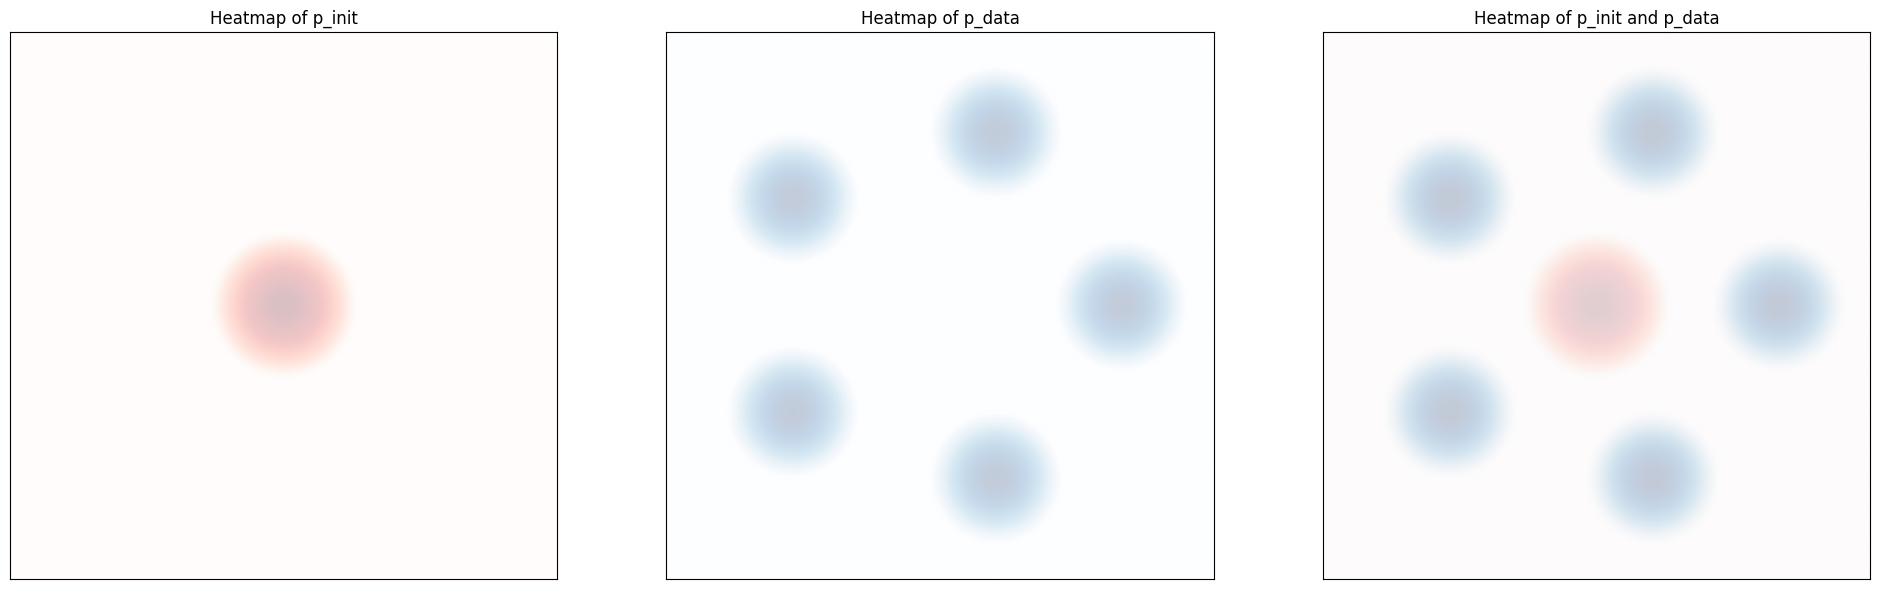

In [8]:
# Visualização dos resultados
p_init = Gaussian.isotropic(dim=2, std=1.0).to(device)
p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
bins = 200

scale = PARAMS["scale"]
x_bounds = [-scale, scale]
y_bounds = [-scale, scale]

axes[0].set_title("Heatmap of p_init")
axes[0].set_xticks([])
axes[0].set_yticks([])
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds,
               bins=200, ax=axes[0], vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))

axes[1].set_title("Heatmap of p_data")
axes[1].set_xticks([])
axes[1].set_yticks([])
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds,
               bins=200, ax=axes[1], vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

axes[2].set_title('Heatmap of p_init and p_data')
axes[2].set_xticks([])
axes[2].set_yticks([])
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, 
               bins=200, ax=axes[2], vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds,
              bins=200, ax=axes[2], vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

# Problema 2.1: Implementando $\alpha_t \ \  e \ \  \beta_t$
Vampos implementar $\alpha_t$ e $\beta_t$ por meio das classes `Alpha` e `Beta`, implementando também as expressões $\dot{\alpha_{t}} = \frac{d}{dt}\alpha_t$ e $\dot{\beta_{t}} = \frac{d}{dt}\beta_{t}$

In [9]:
class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,1)), torch.zeros(1,1)
        )
        # Check alphat(1) = 1
        assert torch.allclose(
            self(torch.ones(1,1)), torch.ones(1,1)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0, self(1.0) = 1.0
        Args:
            -t: time, shape=(num_smaples, 1)
        Returns:
            -alpha_t, shape=(num_samples, 1)
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t
        Args:
            -t: time, shape=(num_samples, 1)
        Returns:
            -d/dt alpha_t, shape=(num_samples, 1)
        """
        t = t.unsqueeze(1) # shape=(num_samples, 1, 1)
        dt = vmap(jacrev(self))(t), # shape = (num_samples, 1, 1, 1, 1)
        return dt.view(-1, 1)


class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1,1)), torch.ones(1,1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1,1)), torch.zeros(1,1)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates beta_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0
        Args:
            -t: time, shape=(num_samples, 1)
        Returns:
            -beta_t, shape=(num_samples, 1)
        """
        pass


    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t
        Args:
            -t: time, shape=(num_samples, 1)
        Returns:
            dt/dt beta_t, shape=(num_samples, 1)
        """
        t = t.unsqueeze(1), # shape=(num_samples, 1, 1)
        dt = vmap(jacrev(self))(t), # shape=(num_samples, 1, 1, 1, 1)
        return dt.view(-1, 1)
        

Nessa seção, usaremos:
$$\alpha_t = t \ \ \ \ e \ \ \ \beta_t = \sqrt{1-t}$$

In [10]:
# Implementando alpha_t = t e beta_t = \sqrt(1-t)
class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """
    
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time, shape=(num_samples, 1)
        Returns:
            - alpha_t, shape=(num_samples, 1)
        """ 
        alpha_t = t
        return alpha_t

        
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time, shape=(num_samples, 1)
        Returns:
            - d/dt alpha_t, shape=(num_samples, 1)
        """ 
        return torch.ones_like(t)

class SquareRootBeta(Beta):
    """
    Implements beta_t = rt(1-t)
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1)
        Returns:
            - beta_t (num_samples, 1)
        """ 
        beta_t = torch.sqrt(torch.ones_like(t) - t)
        return beta_t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1)
        """ 
        return - 0.5 / (torch.sqrt(1 - t) + 1e-4)

In [11]:
class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, alpha: Alpha, beta: Beta):
        p_init = Gaussian.isotropic(p_data.dim, 1.0)
        super().__init__(p_init, p_data)
        self.alpha = alpha
        self.beta = beta

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z ~ p_data(x)
        Args:
            - num_samples: the number of samples
        Returns:
            - z: samples from p(z), (num_samples, dim)
        """
        return p_data.sample(num_samples)
    
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z) = N(alpha_t * z, beta_t**2 * I_d)
        x = alpha_t*z + beta_t*noise
        Args:
            - z: conditioning variable (num_samples, dim)
            - t: time (num_samples, 1)
        Returns:
            - x: samples from p_t(x|z), (num_samples, dim)
        """
        alpha_t = self.alpha(t)
        beta_t = self.beta(t)
        noise = torch.randn_like(z)
        x = alpha_t*z + beta_t*noise
        return x
        
        
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Note: Only defined on t in [0,1)
        Args:
            - x: position variable (num_samples, dim)
            - z: conditioning variable (num_samples, dim)
            - t: time (num_samples, 1)
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, dim)
        """ 
        alpha_t = self.alpha(t)
        beta_t = self.beta(t)
        return (self.alpha.dt(t) - (self.beta.dt(t)/beta_t)*alpha_t)*z + (self.beta.dt(t)/beta_t)*x
        

    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z) = N(alpha_t * z, beta_t**2 * I_d)
        ∇_x log p_t(x|z) = -(x - μ)/σ²
        Note: Only defined on t in [0,1)
        Args:
            - x: position variable (num_samples, dim)
            - z: conditioning variable (num_samples, dim)
            - t: time (num_samples, 1)
        Returns:
            - conditional_score: conditional score (num_samples, dim)
        """ 
        alpha_t = self.alpha(t)
        beta_t = self.beta(t)
        mean = alpha_t * z
        conditional_score = -(x-mean) / (beta_t**2)
        return conditional_score

# 2.2 Testando implementação

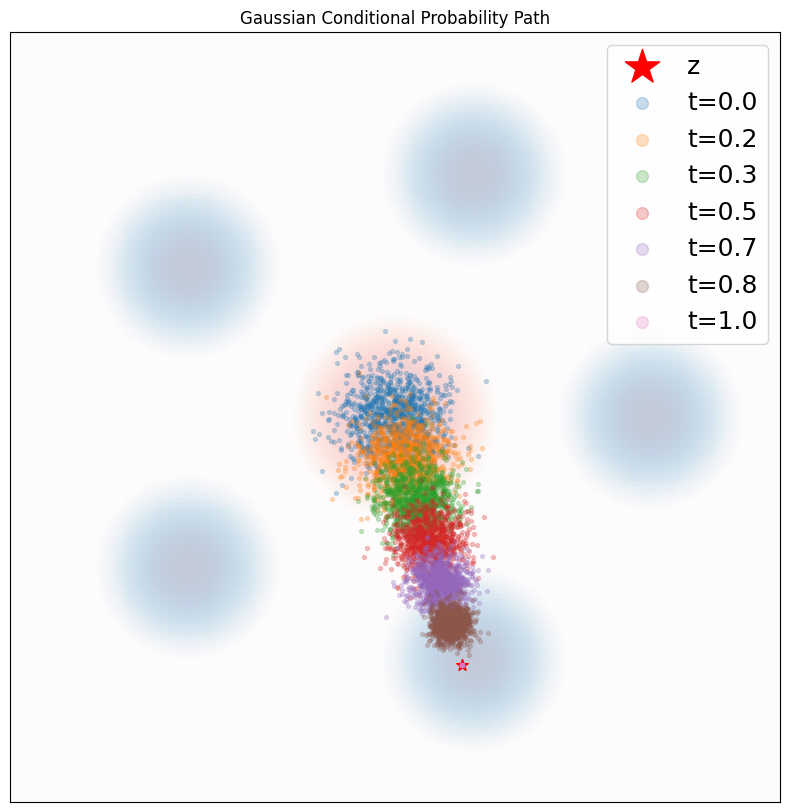

In [12]:
# Contruct conditional probability path
path = GaussianConditionalProbabilityPath(
    p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device),
    alpha = LinearAlpha(),
    beta = SquareRootBeta()
).to(device)

scale = PARAMS["scale"]
x_bounds = [-scale, scale]
y_bounds = [-scale, scale]

plt.figure(figsize=(10,10))
plt.xlim(*x_bounds)
plt.ylim(*y_bounds)
plt.title("Gaussian Conditional Probability Path")

# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

# Sample conditional variable z
z = path.sample_conditioning_variable(1)
ts = torch.linspace(0.0, 1.0, 7).to(device)

# Plot z
plt.scatter(z[:, 0].cpu(), z[:, 1].cpu(), marker='*', color='red', s=75, label='z')
plt.xticks([])
plt.yticks([])

# Plot conditional probability path at each intermediate t
num_samples = 1000
for t in ts:
    zz = z.expand(num_samples, 2)
    tt = t.unsqueeze(0).expand(num_samples, 1) # shape=(samples, 1)
    samples = path.sample_conditional_path(zz, tt) # shape=(samples, 2)
    plt.scatter(samples[:, 0].cpu(), samples[:, 1].cpu(), alpha=0.25, s=8, label=f't={t.item():.1f}')

plt.legend(prop={'size': 18}, markerscale=3)
plt.show()

# Problema 2.3: Campo condicional vetorial

 Podemos definir a probabilidade condicional $u_{t}(x|z)$ como:
 $$u_{t}(x|z) = \Big(\dot{\alpha_{t}}-\frac{\dot{\beta_{t}}}{\beta_{t}}\alpha_{t}\Big) z + \frac{\dot{\beta_{t}}}{\beta_{t}}x$$.

 O desafio agora será implementar o método `conditional_vector_field` para computar o campo condicional vetorial $u_{t}(x|z)$.

 Portanto, as trajetórias condicionais correspondentes a uma EDO serão:
 $$dX_{t} = u_{t}(X_{t}|z)dt, \ \ \ X_{0} = x_{0} = x_{0} \sim p_{init}$$.

In [13]:
class ConditionalVectorFieldEDO(EDO):
    def __init__(self, path: ConditionalProbabilityPath, z: torch.Tensor):
        """
        -Args:
            -path: objeto ConditionalProbabilityPath ao qual este campo vetorial corresponde.
            -z: variável condicional, shape=(1, dim)
        """
        super().__init__()
        self.path = path
        self.z = z

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the conditional vector field u_t(x|z)
        Args:
            -x : estado x, no tempo t, shape=(batch_size, dim)
            -t: tempo, shape=(batch_size, dim)
        Returns:
            - u_{t}(x|z) : shape=(batch_size, dim)
        """
        bs = x.shape[0]
        z = self.z.expand(bs, *self.z.shape[1:])
        return self.path.conditional_vector_field(x, z, t)

100%|██████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 2402.19it/s]


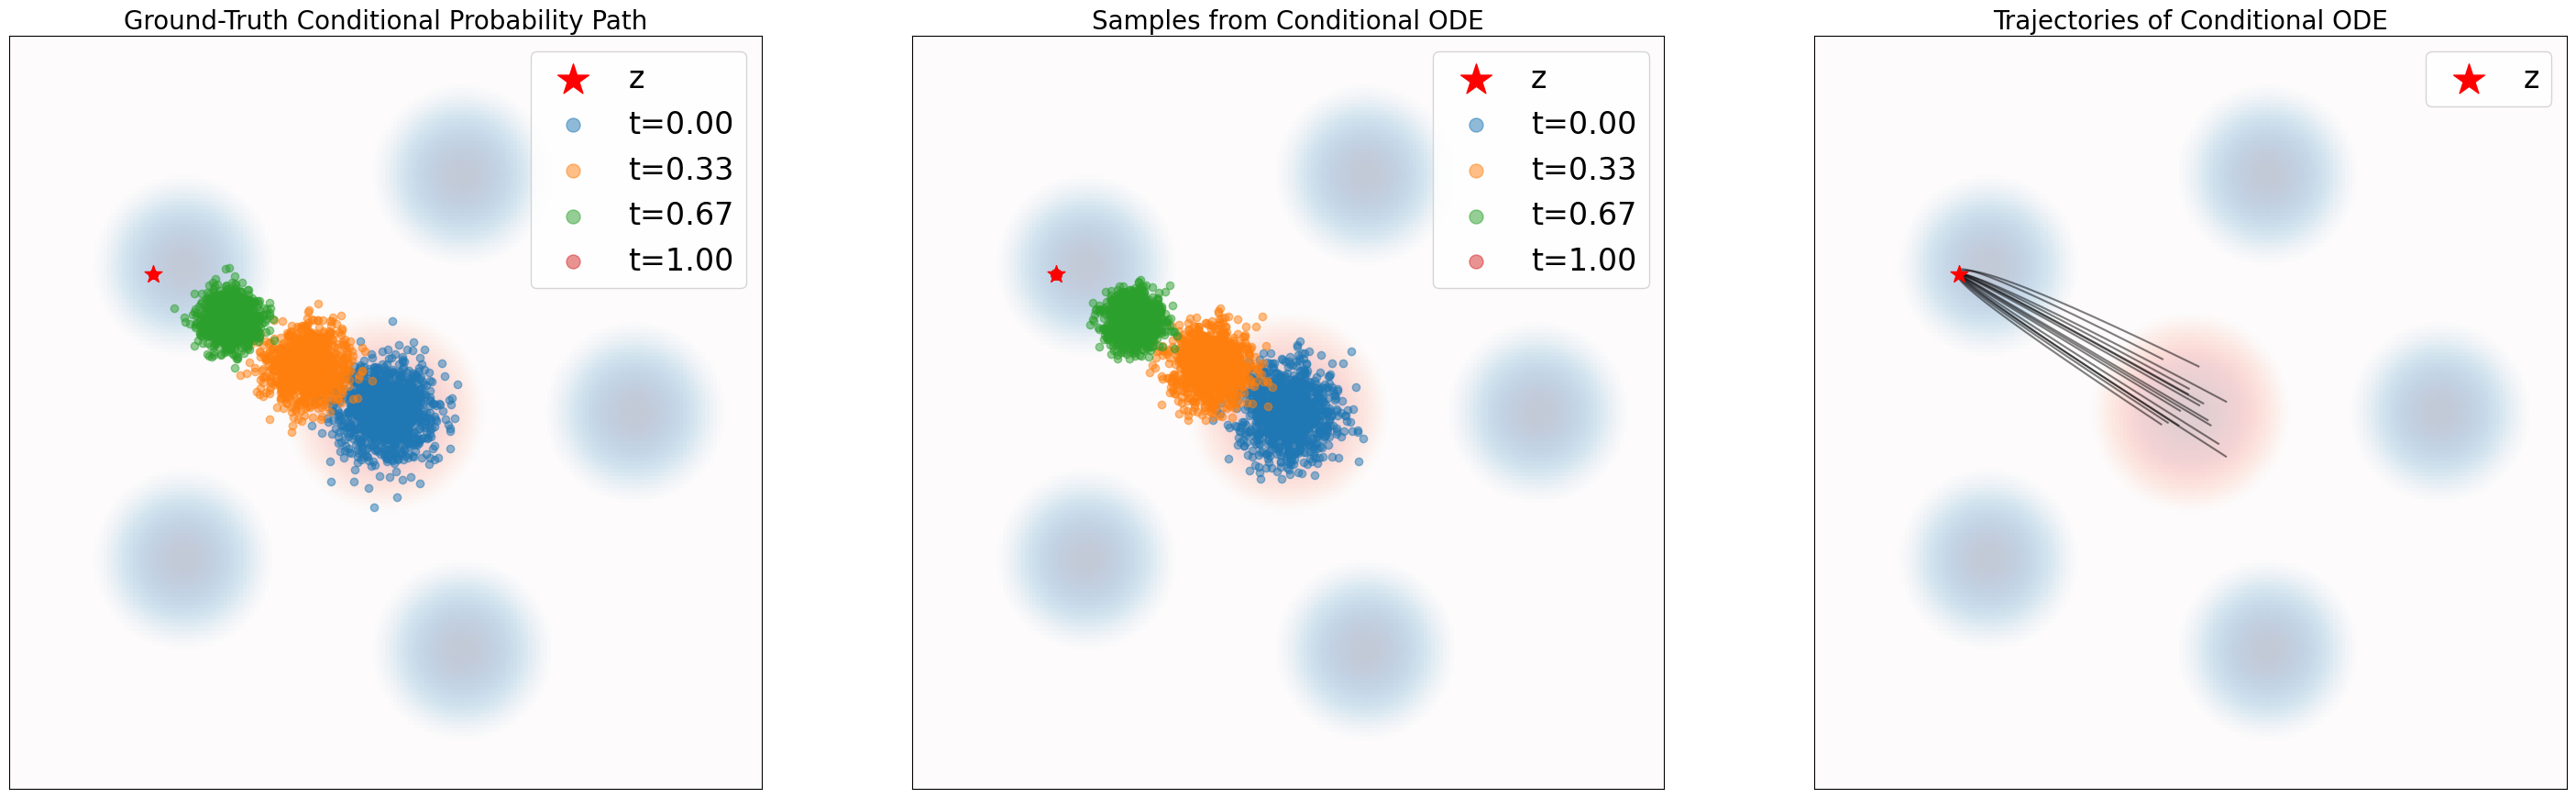

In [14]:
# Run me for Problem 2.3!

#######################
# Change these values #
#######################
num_samples = 1000
num_timesteps = 1000
num_marginals = 3

########################
# Setup path and plot  #
########################

path = GaussianConditionalProbabilityPath(
    p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device), 
    alpha = LinearAlpha(),
    beta = SquareRootBeta()
).to(device)


# Setup figure
fig, axes = plt.subplots(1,3, figsize=(36, 12))
scale = PARAMS["scale"]
legend_size = 24
markerscale = 1.8
x_bounds = [-scale,scale]
y_bounds = [-scale,scale]

# Sample conditioning variable z
torch.cuda.manual_seed(1)
z = path.sample_conditioning_variable(1) # (1,2)

######################################
# Graph samples from conditional ODE #
######################################
ax = axes[1]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Samples from Conditional ODE', fontsize=20)
ax.scatter(z[:,0].cpu(), z[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z

# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))


# Construct integrator and plot trajectories
sigma = 0.5 # Can't make this too high or integration is numerically unstable!
edo = ConditionalVectorFieldEDO(path, z)
simulator = EulerSimulator(edo)
x0 = path.p_init.sample(num_samples) # (num_samples, 2)
ts = torch.linspace(0.0, 1.0, num_timesteps).view(1,-1,1).expand(num_samples,-1,1).to(device) # (num_samples, nts, 1)
xts = simulator.simulate_with_trajectory(x0, ts) # (bs, nts, dim)

# Extract every n-th integration step to plot
every_n = record_every(num_timesteps=num_timesteps, record_every=num_timesteps // num_marginals)
xts_every_n = xts[:,every_n,:] # (bs, nts // n, dim)
ts_every_n = ts[0,every_n] # (nts // n,)
for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].item()
    ax.scatter(xts_every_n[:,plot_idx,0].detach().cpu(), xts_every_n[:,plot_idx,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt:.2f}')
ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)


#########################################
# Graph Trajectories of Conditional ODE #
#########################################
ax = axes[2]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Trajectories of Conditional ODE', fontsize=20)
ax.scatter(z[:,0].cpu(), z[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z


# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

for traj_idx in range(15):
    ax.plot(xts[traj_idx,:,0].detach().cpu(), xts[traj_idx,:,1].detach().cpu(), alpha=0.5, color='black')
ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)


###################################################
# Graph Ground-Truth Conditional Probability Path #
###################################################
ax = axes[0]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Ground-Truth Conditional Probability Path', fontsize=20)
ax.scatter(z[:,0].cpu(), z[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z


for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].unsqueeze(0).expand(num_samples, 1)
    zz = z.expand(num_samples, 2)
    marginal_samples = path.sample_conditional_path(zz, tt)
    ax.scatter(marginal_samples[:,0].detach().cpu(), marginal_samples[:,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt[0,0].item():.2f}')

# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))
ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)

plt.show()

# Problema 2.4: Score condicional

As trajetórias de uma EDE são calculadas pela expressão:
$$dX_{t} = \Big[u_{t}(X_{t}|z) + \frac{1}{2}\sigma_{t}^{2}\nabla_{x}\mathit{log} \ p_{t}(X_{t}|z)\Big]dt + \sigma_{t} dW_{t}, \ \ \ X_{0} = x_{0} \sim p_{init}, $$

Obtida a partir da dinâmica de Langevin da EDO original.$$$$

Nosso objetivo aqui será implementar o método `conditional_score` para computar a distribuição condicional $$\nabla_{x} log\ p_{t}(x|z) = \nabla_{x}N(x; \alpha_{t}z, \beta_{t}^{2}I_{d}) = \frac{\alpha_{t}z - x}{\beta_{t}^{2}}$$

In [15]:
class ConditionalVectorFieldEDE(EDE):
    def __init__(self, path: ConditionalProbabilityPath, z: torch.Tensor, sigma: float):
        """
        Args:
            - path: objeto que representa o caminho de probabilidade condicional o qual este 
            campo vetorial corresponde
            - z: variável condicional, (1, ...)
        """
        super().__init__()
        self.path = path
        self.z = z
        self.sigma = sigma 

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o campo vetorial condicioanl u_t(x|z)
        Args:
            -x: estado no tempo t, shape=(bs, dim)
            -t: tempo, shape=(bs, )
        Returns:
            -u_t(x|z): shape=(bs, dim)
        """
        bs = x.shape[0]
        z = self.z.expand(bs, *self.z.shape[1:])
        return self.path.conditional_vector_field(x,z,t) + 0.5*self.sigma**2*self.conditional_score(x,z,t)

    def diffusion_coefficient(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            -x: estado no tempo t, shape=(bs,dim)
            -t: tempo, shape=(bs,)
        Returns:
            -u_t(x|z): shape=(bs,dim)
        """
        return self.sigma*torch.randn_like(x)

    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z) = N(alpha_t * z, beta_t**2 * I_d)
        ∇_x log p_t(x|z) = -(x - μ)/σ²
        Note: Only defined on t in [0,1)
        Args:
            - x: position variable (num_samples, dim)
            - z: conditioning variable (num_samples, dim)
            - t: time (num_samples, 1)
        Returns:
            - conditional_score: conditional score (num_samples, dim)
        """ 
        alpha_t = self.path.alpha(t)
        beta_t = self.path.beta(t)
        mean = alpha_t * z
        conditional_score = -(x-mean) / (beta_t**2)
        return conditional_score

Podemos observar um comportamento inusitado para valores elevados de $\sigma$.
$$\nabla_{x} \ log \ p_{t}(x|z) = \frac{\alpha_{t}z - x}{\beta_{t}^{2}}$$
Dentro da EDE:
$$ dX_{t} = \Big[u_{t}(X_{t}|z) + \frac{1}{2}\sigma^{2}\nabla_{x} \ log \ p_{t}(X_{t}|z)\Big]dt + \sigma dW_{t}$$
Leva a
$$ dX_{t} = \Big[u_{t}(X_{t}|z) + \frac{1}{2}\sigma^{2}\Big(\frac{\alpha_{t}z - X_{t}}{\beta_{t}^{2}}\Big)\Big]dt + \sigma dW_{t}$$

Quando $t \rightarrow 1$, $\beta_{t} \rightarrow 0$, então o segundo termo do coeficiente de drift explode (escalando de forma quadrática com $\sigma$). Com um número finite de passos em uma simulação, não conseguiríamos simular de forma acurada essa explosão, tendo que lidar com problemas numéricos. Na prática, esse problema pode ser resolvido definido $\sigma_{t} = \beta_{t} $, de modo que esse efeito seja cancelado pela dimunição gradual do nível de ruído durante a simulação. 

100%|██████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 1765.59it/s]


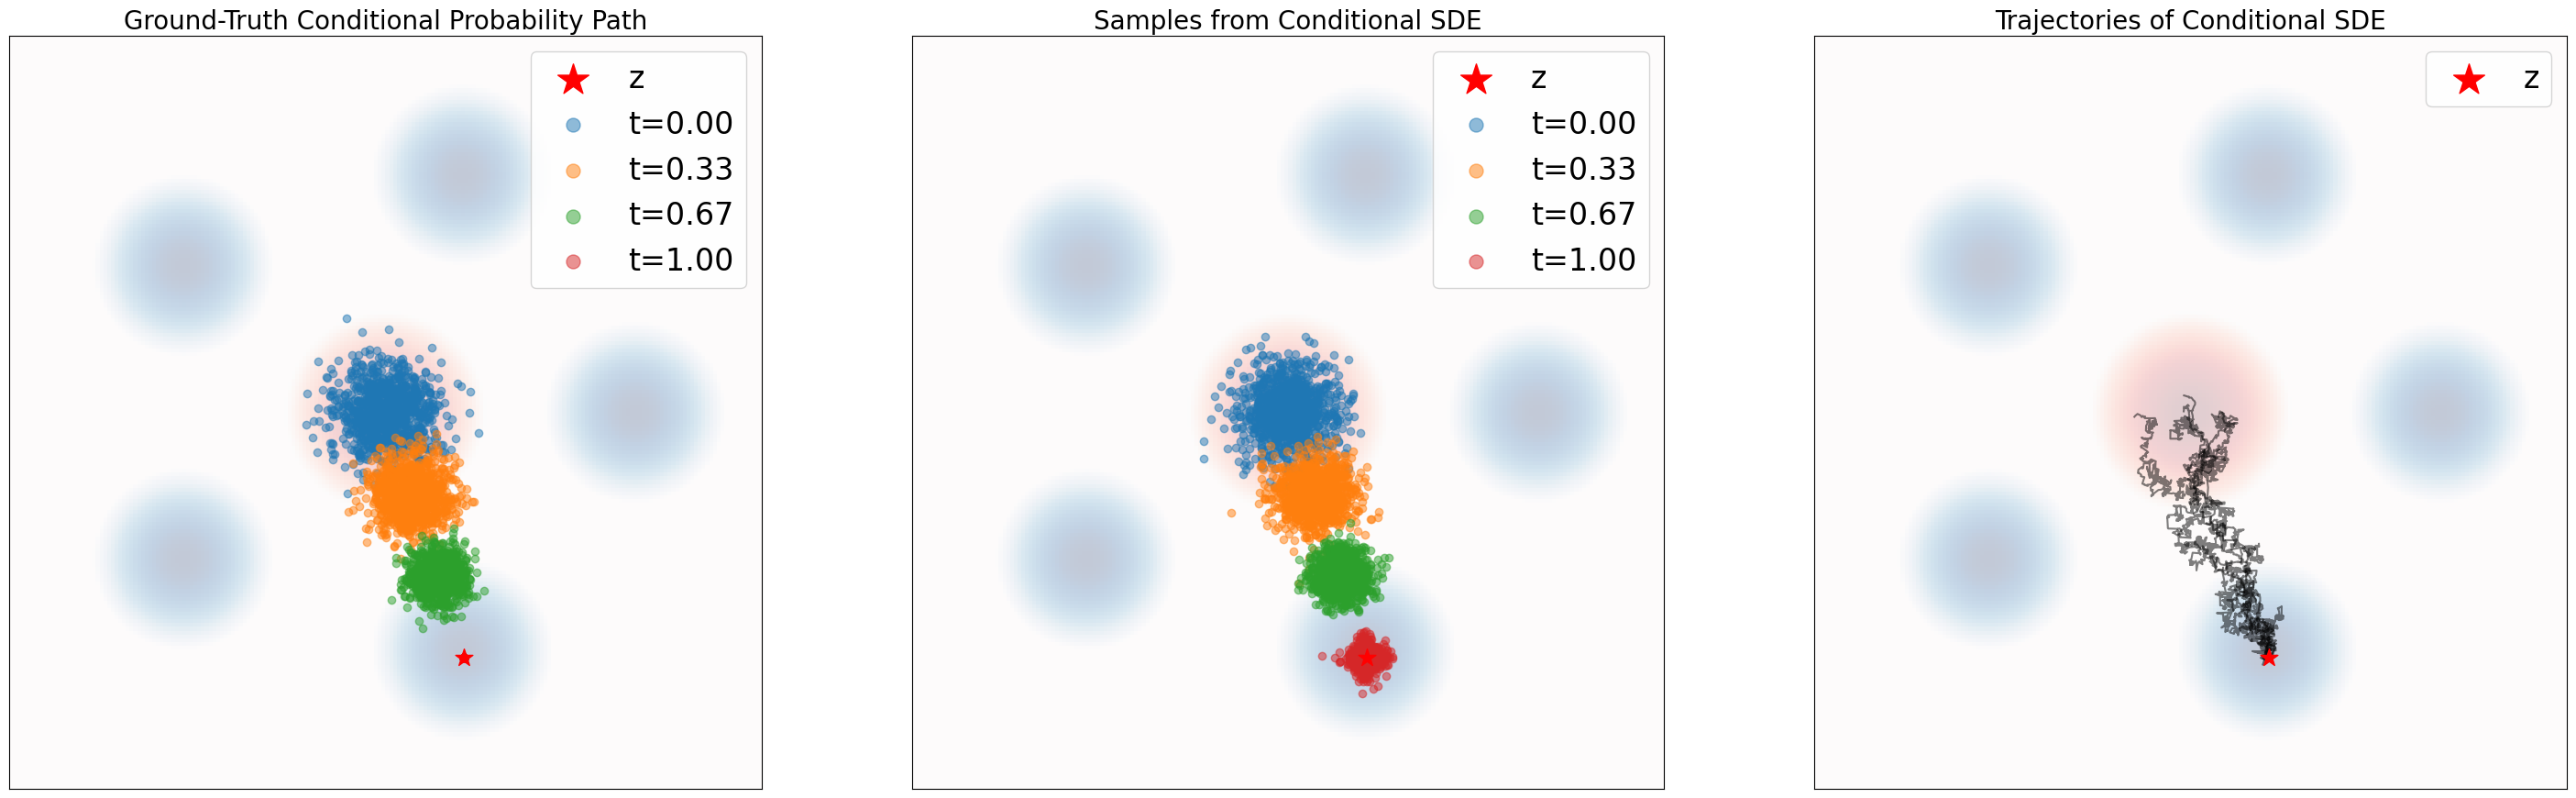

In [16]:
# Run me for Problem 2.3!

#######################
# Change these values #
#######################
num_samples = 1000
num_timesteps = 1000
num_marginals = 3
sigma = 2.5

########################
# Setup path and plot  #
########################

path = GaussianConditionalProbabilityPath(
    p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device), 
    alpha = LinearAlpha(),
    beta = SquareRootBeta()
).to(device)


# Setup figure
fig, axes = plt.subplots(1,3, figsize=(36, 12))
scale = PARAMS["scale"]
x_bounds = [-scale,scale]
y_bounds = [-scale,scale]
legend_size = 24
markerscale = 1.8

# Sample conditioning variable z
torch.cuda.manual_seed(1)
z = path.sample_conditioning_variable(1) # (1,2)

######################################
# Graph Samples from Conditional SDE #
######################################
ax = axes[1]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Samples from Conditional SDE', fontsize=20)
ax.scatter(z[:,0].cpu(), z[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z

# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))


# Construct integrator and plot trajectories
sde = ConditionalVectorFieldEDE(path, z, sigma)
simulator = EulerMaruyamaSimulator(sde)
x0 = path.p_init.sample(num_samples) # (num_samples, 2)
ts = torch.linspace(0.0, 1.0, num_timesteps).view(1,-1,1).expand(num_samples,-1,1).to(device) # (num_samples, nts, 1)
xts = simulator.simulate_with_trajectory(x0, ts) # (bs, nts, dim)

# Extract every n-th integration step to plot
every_n = record_every(num_timesteps=num_timesteps, record_every=num_timesteps // num_marginals)
xts_every_n = xts[:,every_n,:] # (bs, nts // n, dim)
ts_every_n = ts[0,every_n] # (nts // n,)
for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].item()
    ax.scatter(xts_every_n[:,plot_idx,0].detach().cpu(), xts_every_n[:,plot_idx,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt:.2f}')
ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)


##########################################
# Graph Trajectories of Conditional SDE  #
##########################################
ax = axes[2]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Trajectories of Conditional SDE', fontsize=20)
ax.scatter(z[:,0].cpu(), z[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z


# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

for traj_idx in range(5):
    ax.plot(xts[traj_idx,:,0].detach().cpu(), xts[traj_idx,:,1].detach().cpu(), alpha=0.5, color='black')
ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)


###################################################
# Graph Ground-Truth Conditional Probability Path #
###################################################
ax = axes[0]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Ground-Truth Conditional Probability Path', fontsize=20)
ax.scatter(z[:,0].cpu(), z[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z


for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].unsqueeze(0).expand(num_samples, 1)
    zz = z.expand(num_samples, 2)
    marginal_samples = path.sample_conditional_path(zz, tt)
    ax.scatter(marginal_samples[:,0].detach().cpu(), marginal_samples[:,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt[0,0].item():.2f}')

# Plot source and target
imshow_density(density=p_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))
ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)

plt.show()

# Parte 3: Flow Matching e Score Matching com caminhos de probabilidade condicionais gaussianas

Problema 3.1 :  Flow Matching com Caminhos de probabilidades condicionais gaussianas.

Nosso objetivo é aprender o campo vetorial marginal $u_{t}(x)$ dado que
$$ u_{t}^{ref}(x) = \mathbb{E}_{z\sim p_{t}(z|x)} \Big[u_{x}^{ref}(x|z)\Big]$$

Infelizmente, não temos acesso exato a $u_{t}^{ref}(x)$. Portanto, temos que aproximá-lo com uma rede neural $u_{t}(x)^{\theta}$
$$u_{t}^{ref}(x) = argmin_{u_{t}(x)}\ \mathbb{E}_{z\sim p_{t}(z|x)}\Big[||u_{t}(x) - u_{t}^{ref}(x|z)||^{2}\Big]$$
Para obter a função de custo
$$\mathcal{L}_{CFM}(\theta) = \mathbf{E}_{z\sim p(z), x\sim p_{t}(x|z)}\Big[||u_{t}^{\theta}(x) - u_{t}^{ref}(x|z)||^{2}\Big]$$ 

Para modelar $u_{t}^{\theta}(x)$, usaremos uma arquitetura MLP simples. Esse arquitetura de rede neural irá receber $x$ e $t$ e retornar o vetor aprendido $u_{t}^{\theta}(x)$.

In [17]:
def build_mlp(dims: List[int], activation: Type[torch.nn.Module] = torch.nn.SiLU):
    mlp = []
    for idx in range(len(dims) - 1):
        mlp.append(torch.nn.Linear(dims[idx], dims[idx + 1]))
        if idx < len(dims) -2:
            mlp.append(activation())
    return torch.nn.Sequential(*mlp)

class MLPVectorField(torch.nn.Module):
    """
    MLP - parameterization of the learned vector field u_{t}^{\theta}(x)
    """
    def __init__(self, dim: int, hiddens: List[int]):
        super().__init__()
        self.dim = dim
        self.net = build_mlp([dim + 1] + hiddens + [dim])

    def forward(self, x: torch.Tensor, t = torch.Tensor):
        """

        Args:
        - x : (bs, dim)
        Returns:
        - u_t^theta(x): (bs, dim)
        """
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt)


class Trainer(ABC):
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def get_optimizer(self, lr: float):
        return torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, num_epochs: int, device: torch.device, lr: float = 1e-3, **kwargs) -> torch.Tensor:
        self.model.to(device)
        opt = self.get_optimizer(lr)
        self.model.train()

        pbar = tqdm(enumerate(range(num_epochs)))
        for idx, epoch in pbar:
            opt.zero_grad()
            loss = self.get_train_loss(**kwargs)
            loss.backward()
            opt.step()
            pbar.set_description(f"Epoch {idx}, loss: {loss.item()}")

        self.model.eval()

# Atividade - implementar a função 'get_train_loss'
class ConditionalFlowMatchingTrainer(Trainer):
    def __init__(self, path: ConditionalProbabilityPath, model: MLPVectorField, **kwargs):
        super().__init__(model, **kwargs)
        self.path = path

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        z = self.path.p_data.sample(batch_size)
        t = torch.rand(batch_size, 1).to(z.device)
        x = self.path.sample_conditional_path(z, t)
        ut_theta = self.model(x, t)
        ut_ref = self.path.conditional_vector_field(x, z, t)
        return torch.mean((ut_theta - ut_ref)**2)




# Testando implementação: 

Epoch 4999, loss: 10.657783508300781: : 5000it [00:28, 174.84it/s]
100%|██████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 1377.30it/s]


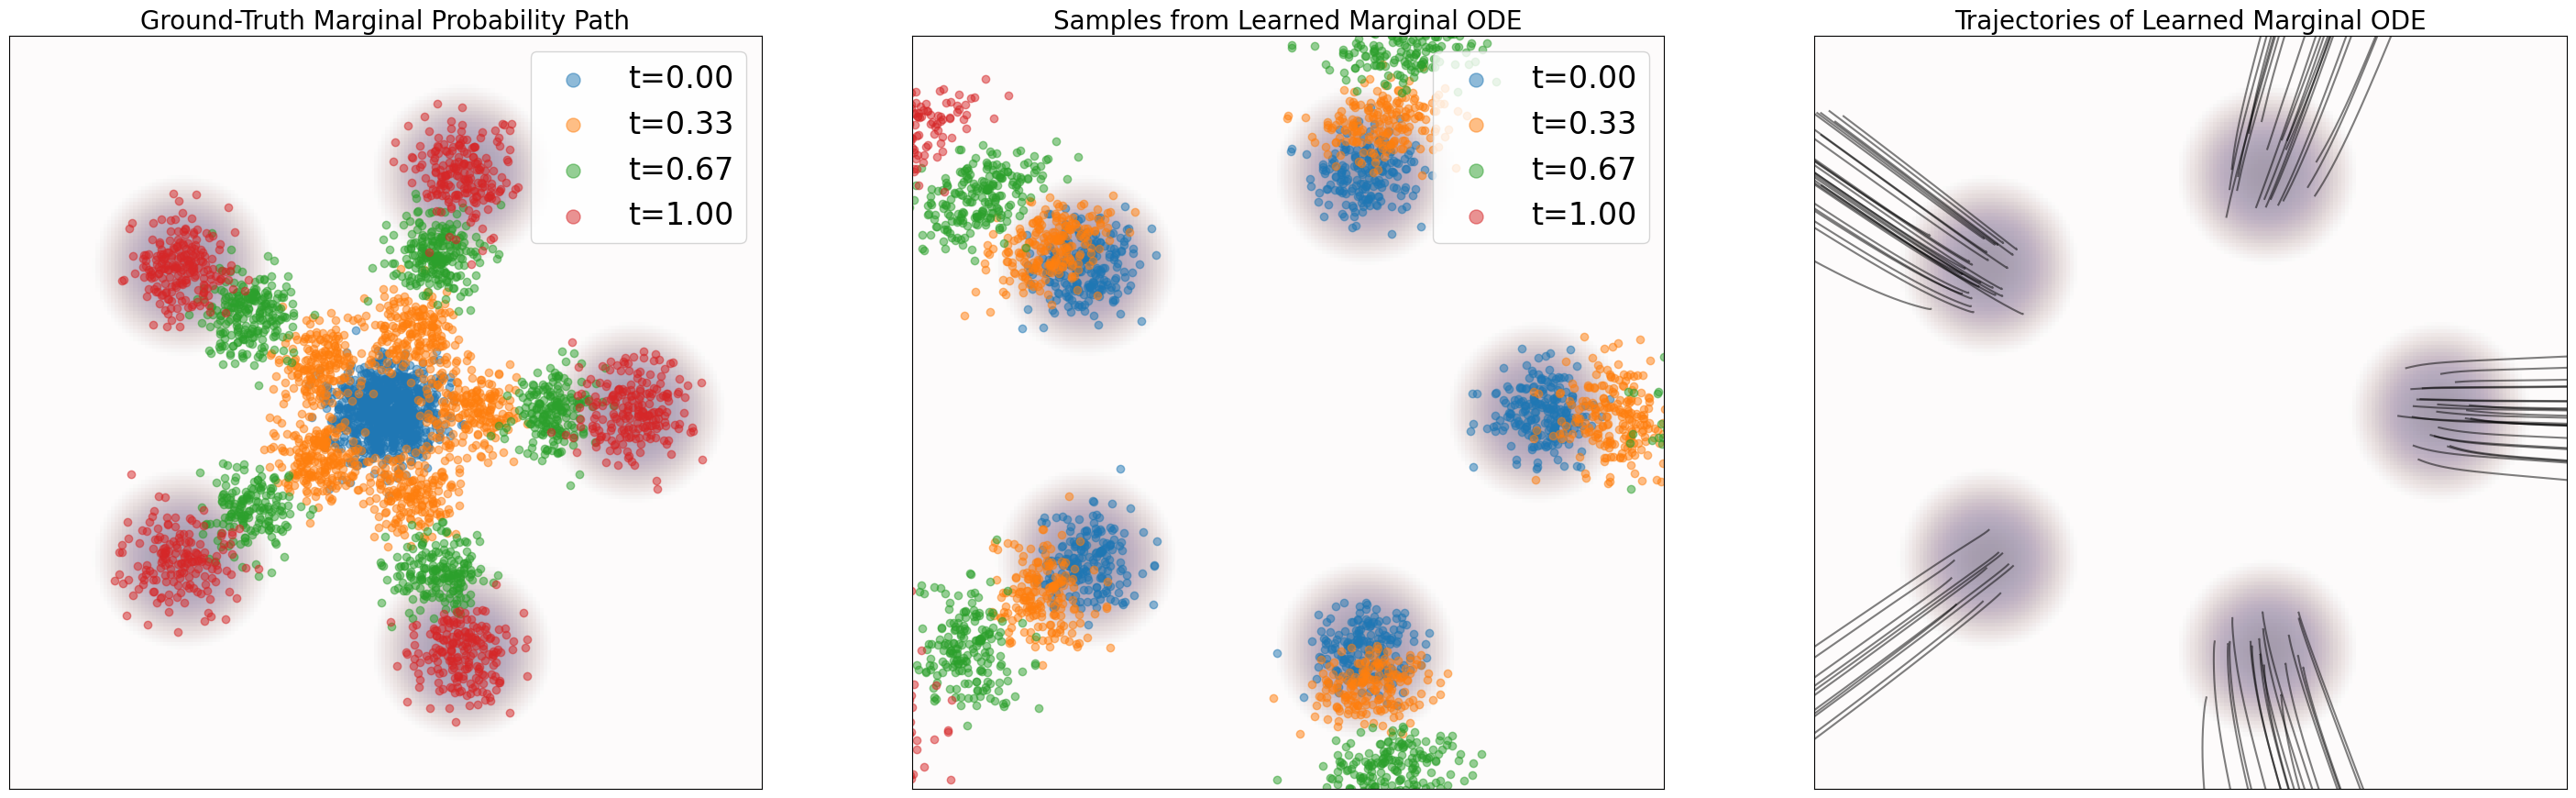

In [18]:
# Construindo caminho de probabilidade gaussiana
path = GaussianConditionalProbabilityPath(
    p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device),
    alpha = LinearAlpha(),
    beta = SquareRootBeta()
).to(device)

# Construindo um campo vetorial aprendível
flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construindo o trainer
trainer = ConditionalFlowMatchingTrainer(path, flow_model)
losses = trainer.train(num_epochs=5000, device=device, lr=1e-3, batch_size=1000)


class LearnedVectorFieldEDO(EDO):
    def __init__(self, net: MLPVectorField):
        self.net = net

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - x: shape= (bs, dim)
            - t : shape=(bs, dim)
        Returns:
            - u_t: shape=(bs,dim)
        """
        return self.net(x, t)



#######################
# Change these values #
#######################
num_samples = 1000
num_timesteps = 1000
num_marginals = 3


##############
# Setup Plot #
##############

scale = PARAMS["scale"]
x_bounds = [-scale,scale]
y_bounds = [-scale,scale]
legend_size=24
markerscale=1.8

# Setup figure
fig, axes = plt.subplots(1,3, figsize=(36, 12))

###########################################
# Graph Samples from Learned Marginal ODE #
###########################################
ax = axes[1]

ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Samples from Learned Marginal ODE", fontsize=20)

# Plot source and target
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))


# Construct integrator and plot trajectories
ode = LearnedVectorFieldEDO(flow_model)
simulator = EulerSimulator(ode)
x0 = path.p_data.sample(num_samples) # (num_samples, 2)
ts = torch.linspace(0.0, 1.0, num_timesteps).view(1,-1,1).expand(num_samples,-1,1).to(device) # (num_samples, nts, 1)
xts = simulator.simulate_with_trajectory(x0, ts) # (bs, nts, dim)

# Extract every n-th integration step to plot
every_n = record_every(num_timesteps=num_timesteps, record_every=num_timesteps // num_marginals)
xts_every_n = xts[:,every_n,:] # (bs, nts // n, dim)
ts_every_n = ts[0,every_n] # (nts // n,)
for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].item()
    ax.scatter(xts_every_n[:,plot_idx,0].detach().cpu(), xts_every_n[:,plot_idx,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt:.2f}')

ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)

##############################################
# Graph Trajectories of Learned Marginal ODE #
##############################################
ax = axes[2]
ax.set_title("Trajectories of Learned Marginal ODE", fontsize=20)
ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])

# Plot source and target
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

for traj_idx in range(num_samples // 10):
    ax.plot(xts[traj_idx,:,0].detach().cpu(), xts[traj_idx,:,1].detach().cpu(), alpha=0.5, color='black')

################################################
# Graph Ground-Truth Marginal Probability Path #
################################################
ax = axes[0]
ax.set_title("Ground-Truth Marginal Probability Path", fontsize=20)
ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])

for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].unsqueeze(0).expand(num_samples, 1)
    marginal_samples = path.sample_marginal_path(tt)
    ax.scatter(marginal_samples[:,0].detach().cpu(), marginal_samples[:,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt[0,0].item():.2f}')

# Plot source and target
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)
    
plt.show()

### Problema 3.2 : Score Matching com caminhos de probabilidades condicionais 

Recordando da dinamica de Langevin, fazemos
$$dX_{t} = \Big[u_{t}^{ref}(x) + \frac{1}{2}\sigma^{2}\nabla \ log \ p_{t}(x)\Big]dt + \sigma dW_{t}.$$
Substituindo o campo vetorial pela nossa aproximação dada por uma rede neural:
$$dX_{t} = \Big[u_{t}^{\theta}(x) + \frac{1}{2}\sigma^{2}\nabla \ log \ p_{t}(x)\Big]dt + \sigma dW_{t}.$$

Temos apenas um problema. Qual o score marginal $\nabla \ log \ p_{t}(x)$? Podemos lembrar que:
$$\nabla \ log \ p_{t}(x) = \mathbb{E}_{z\sim p_{t}(z|x)}\Big[ \nabla \ log \ p_{t}(x|z)\Big]$$
Então, imediatamente, temos
$$ \nabla \ log \ p_{t}(x) = argmin_{s_{t}(x)} \ \mathbb{E}_{z\sim p(z), x\sim p_{t}(x|z)}\Big[||s_{t}(x) - \nabla \ log \ p_{t}(x|z)||^{2}\Big].$$

De modo que obtemos o erro condicional score matching, $\mathcal{L}_{CSM}$:
$$\mathcal{L}_{CSM} \triangleq \mathbb{E}_{t\sim \mathcal{U}(0,1), z\sim p(z), x\sim p_{t}(x|z)}\Big[||s_{t}^{\theta}(x) - \nabla \ log \ p_{t}(x|z)||^{2}\Big]$$

Onde, nós parametrizamos $s_{t}^{\theta}(x) : \mathbb{R}^{2} \rightarrow \mathbb{R}^{2}$, como um simples modelo MLP, assim como fizemos para $u_{t}^{\theta}(x)$.

In [19]:
class MLPScore(torch.nn.Module):
    """
    MLP-parameterization of the learned score field
    """
    def __init__(self, dim: int, hiddens: List[int]):
        super().__init__()
        self.dim = dim
        self.net = build_mlp([dim + 1] + hiddens + [dim])

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        Args:
        - x: (bs, dim)
        Returns:
        - s_t^theta(x): (bs, dim)
        """
        xt = torch.cat([x,t], dim=-1)
        return self.net(xt)        
        
class ConditionalScoreMatchingTrainer(Trainer):
    def __init__(self, path: ConditionalProbabilityPath, model: MLPScore, **kwargs):
        super().__init__(model, **kwargs)
        self.path = path

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        z = self.path.p_data.sample(batch_size)
        t = torch.rand(batch_size, 1).to(z.device)
        x = self.path.sample_conditional_path(z, t)
        st_theta = self.model(x, t)
        st_ref = self.path.conditional_score(x, z, t)
        return torch.mean((st_theta - st_ref)**2)

        

# Testando implementação:

In [20]:
# Construct conditional probability path
path = GaussianConditionalProbabilityPath(
    p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device), 
    alpha = LinearAlpha(),
    beta = SquareRootBeta()
).to(device)

# Construct learnable vector field
score_model = MLPScore(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalScoreMatchingTrainer(path, score_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=1000)

Epoch 999, loss: 6.635123252868652: : 1000it [00:05, 176.63it/s]


In [21]:
class LangevinFlowSDE(EDE):
    def __init__(self, flow_model: MLPVectorField, score_model: MLPScore, sigma: float):
        """
        Args:
        - path: the ConditionalProbabilityPath object to which this vector field corresponds
        - z: the conditioning variable, (1, dim)
        """
        super().__init__()
        self.flow_model = flow_model
        self.score_model = score_model
        self.sigma = sigma

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - x: state at time t, shape (bs, dim)
            - t: time, shape (bs,.)
        Returns:
            - u_t(x|z): shape (batch_size, dim)
        """
        return self.flow_model(x,t) + 0.5 * self.sigma ** 2 * self.score_model(x, t)

    def diffusion_coefficient(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - x: state at time t, shape (bs, dim)
            - t: time, shape (bs,.)
        Returns:
            - u_t(x|z): shape (batch_size, dim)
        """
        return self.sigma * torch.randn_like(x)

100%|███████████████████████████████████████████████████████████████████████████████| 299/299 [00:00<00:00, 670.56it/s]


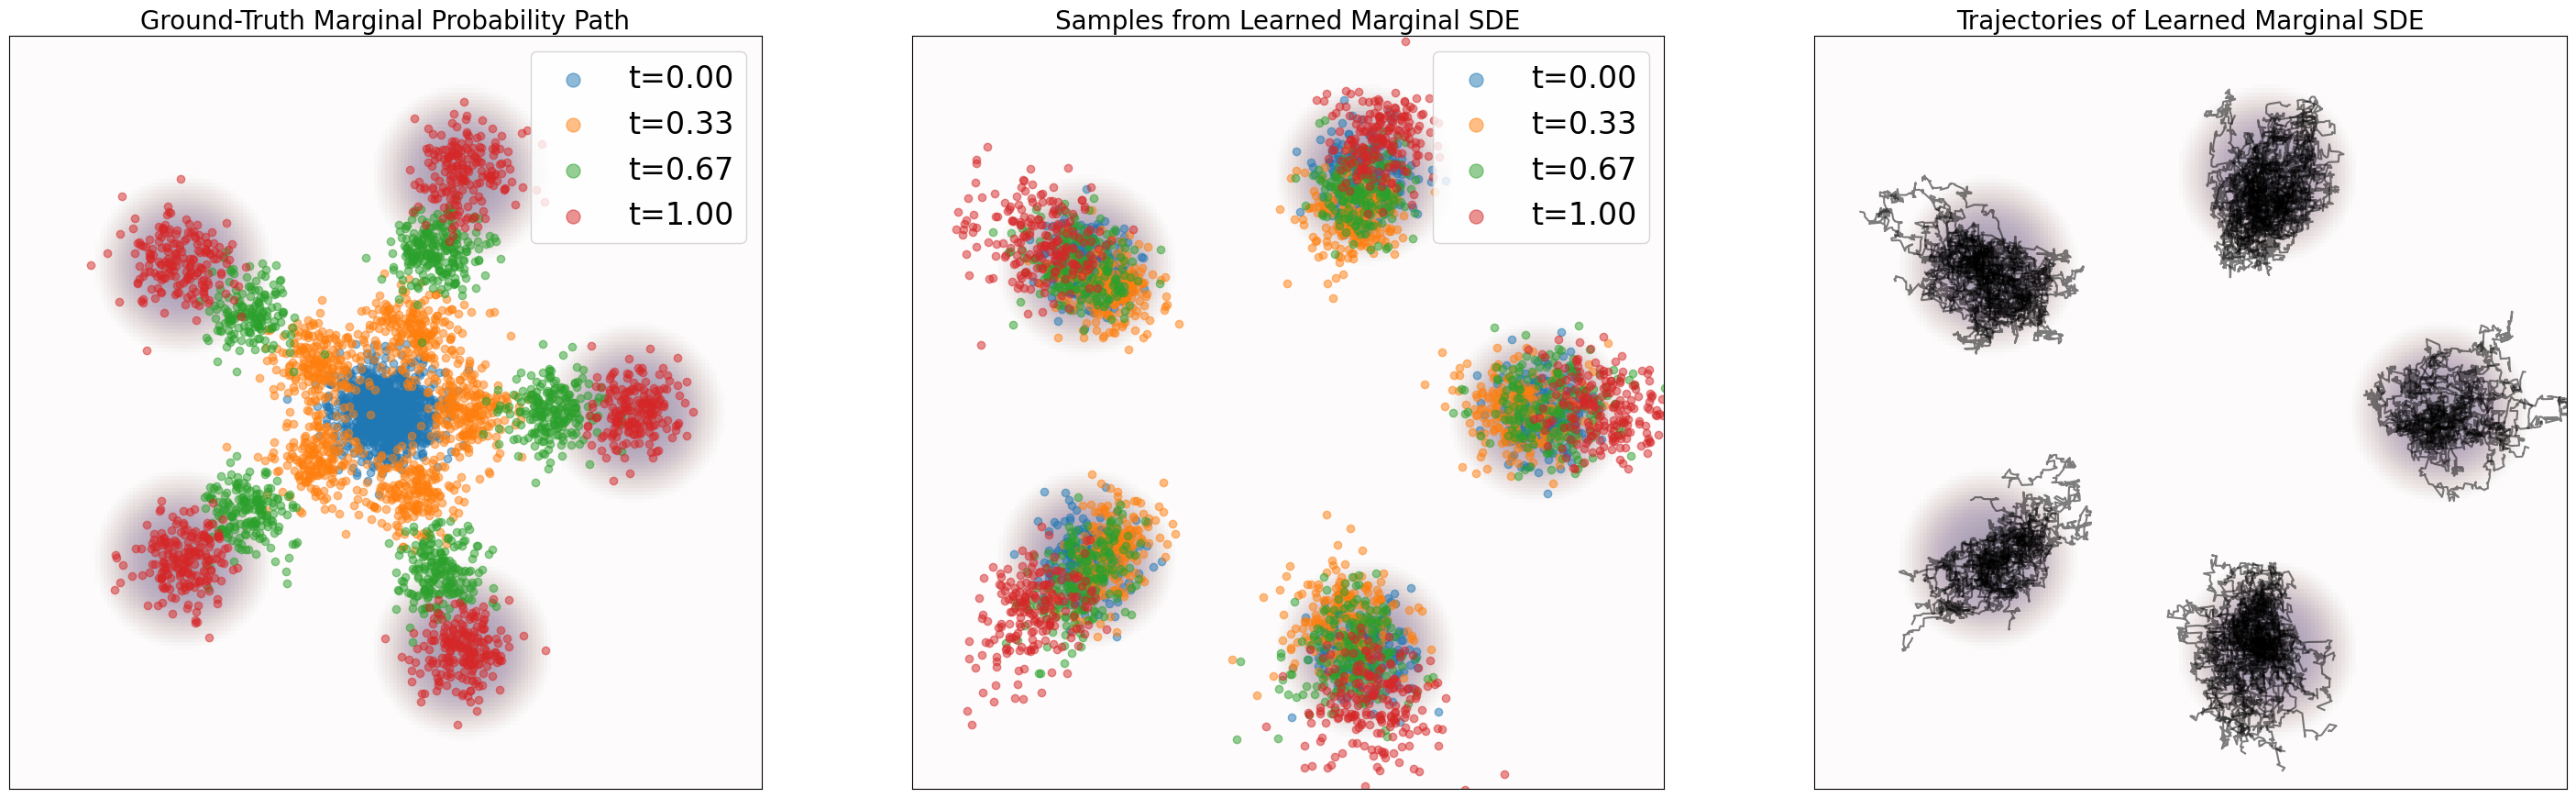

In [22]:
#######################
# Change these values #
#######################
num_samples = 1000
num_timesteps = 300
num_marginals = 3
sigma = 2.0 # Don't set sigma too large or you'll get numerical issues!


##############
# Setup Plot #
##############

scale = PARAMS["scale"]
x_bounds = [-scale,scale]
y_bounds = [-scale,scale]
legend_size = 24
markerscale = 1.8

# Setup figure
fig, axes = plt.subplots(1,3, figsize=(36, 12))

###########################################
# Graph Samples from Learned Marginal SDE #
###########################################
ax = axes[1]
ax.set_title("Samples from Learned Marginal SDE", fontsize=20)
ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])

# Plot source and target
imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))


# Construct integrator and plot trajectories
sde = LangevinFlowSDE(flow_model, score_model, sigma)
simulator = EulerMaruyamaSimulator(sde)
x0 = path.p_data.sample(num_samples) # (num_samples, 2)
ts = torch.linspace(0.0, 1.0, num_timesteps).view(1,-1,1).expand(num_samples,-1,1).to(device) # (num_samples, nts, 1)
xts = simulator.simulate_with_trajectory(x0, ts) # (bs, nts, dim)

# Extract every n-th integration step to plot
every_n = record_every(num_timesteps=num_timesteps, record_every=num_timesteps // num_marginals)
xts_every_n = xts[:,every_n,:] # (bs, nts // n, dim)
ts_every_n = ts[0,every_n] # (nts // n,)
for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].item()
    ax.scatter(xts_every_n[:,plot_idx,0].detach().cpu(), xts_every_n[:,plot_idx,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt:.2f}')

ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)

###############################################
# Graph Trajectories of Learned Marginal SDE  #
###############################################
ax = axes[2]
ax.set_title("Trajectories of Learned Marginal SDE", fontsize=20)
ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])

# Plot source and target
imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

for traj_idx in range(num_samples // 10):
    ax.plot(xts[traj_idx,:,0].detach().cpu(), xts[traj_idx,:,1].detach().cpu(), alpha=0.5, color='black')

################################################
# Graph Ground-Truth Marginal Probability Path #
################################################
ax = axes[0]
ax.set_title("Ground-Truth Marginal Probability Path", fontsize=20)
ax.set_xlim(*x_bounds)
ax.set_ylim(*y_bounds)
ax.set_xticks([])
ax.set_yticks([])

for plot_idx in range(xts_every_n.shape[1]):
    tt = ts_every_n[plot_idx].unsqueeze(0).expand(num_samples, 1)
    marginal_samples = path.sample_marginal_path(tt)
    ax.scatter(marginal_samples[:,0].detach().cpu(), marginal_samples[:,1].detach().cpu(), marker='o', alpha=0.5, label=f't={tt[0,0].item():.2f}')

# Plot source and target
imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

ax.legend(prop={'size': legend_size}, loc='upper right', markerscale=markerscale)
    
plt.show()

# Questão 3.3: Derivando o Score Marginal a partir do Fluxo Marginal

Lembrnado que o vetor $u_{t}^{ref}(x)$que define os caminhos de probabilidade Gaussiana pode ser definido como
$$u_{t}^{ref}(x) = a_{t}(x) + b_{t}\nabla\log\ p_{t}^{ref}(x)$$
Onde $(a_{t}, b_{t}) = \Big (\frac{\dot{\alpha}_{t}}{\alpha_{t}}, \beta_{t}^{2}\frac{\dot{\alpha}_{t}}{\alpha_{t}} - \dot{\beta}_{t}^{2}\beta_{t}\Big)$. Rearranjando esse termo:
$$\nabla\log\ p_{t}^{ref}(x) = \frac{u_{t}^{ref}(x)-\alpha_{t}x}{b_{t}}$$
Então podemos aproveitar do fato que temos $u_{t}^{\theta}(x)$ treinado, para reparametrizar $s_{t}^{\theta}(x)$ via
$$\tilde{s}_{t}^{\theta}(x) = \frac{u_{t}^{\theta}(x)-\alpha_{t}x}{b_{t}} = \frac{\alpha_{t}u_{t}^{ref}x-\dot{\alpha}_{t}x}{\beta_{t}^{2}\dot{\alpha}_{t}-\alpha\dot{\beta}_{t}\beta_{t}}$$
Podemos assumir essa expressão desde que $\beta_{t}^{2}\dot{\alpha}_{t}x - \alpha\dot{\beta}_{t}\beta_{t} \neq 0$ (o que é verdade para $t\in [0,1]$, através da monotonicidade).

Definindo $\alpha_{t} = t$ e $\beta_{t} = \sqrt{1-t}$ e lembrando que $\dot{\alpha}_{t} = \frac{\partial \alpha_{t}}{\partial t}$ e $\dot{\beta}_{t} = \frac{\partial \beta{t}}{\partial t}$, desenvolvemos o denominador de $\tilde{s}_{t}^{\theta}(x)$: 

$$
\begin{align}
\beta_{t}^{2}\dot{\alpha}_{t}-\alpha_{t}\dot{\beta}_{t}\beta_{t} &= \beta_{t}^{2}\frac{\partial \alpha_{t}}{\partial t}-\alpha_{t}\frac{\partial\beta_{t}}{\partial t}\beta_{t} 
\\
&= \Big(\sqrt{1-t}\Big)^{2}\frac{\partial (t)}{\partial t} - t\frac{\partial}{\partial t}(1-t)^{\frac{1}{2}}\sqrt{1-t} \\
&= 1-t - \frac{1}{2}t(1-t)^{-\frac{1}{2}}(-1)(1-t)^{\frac{1}{2}} \\
&= 1-t + \frac{t}{2} = 1-\frac{t}{2}
\end{align}
$$
Logo,
$$\beta_{t}^{2}\dot{\alpha}_{t} - \alpha_{t}\dot{\beta}_{t}\beta_{t} = 
\begin{cases}
1 - \frac{t}{2}, & \text{se}\ t \in [0,1], \\
0, & \text{se}\ t=1
\end{cases}
$$
Afim de contornar o caso em que $t=1.0$, vamos considerá-lo como $t=1-\varepsilon$, para $\varepsilon\approx 0$.

Tarefa: Implementar $\tilde{s}_{t}^{\theta}(x)$ no método ``ScoreFromVectorField.forward``:

In [23]:
class ScoreFromVectorField(torch.nn.Module):
    """
    Parameterization of score via learrned vector field (for the special case of a Gaussian conditional probability path)
    """
    def __init__(self, vector_field: MLPVectorField, alpha: Alpha, beta: Beta):
        super().__init__()
        self.vector_field = vector_field
        self.alpha = alpha 
        self.beta = beta

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        Args:
            -x: (bs, dim)
        Returns:
            - score: (bs, dim)
        """
        if t.dim() == 1:
            t - t.unsqueeze(-1)
        t_safe = torch.clamp(t, max=1.0 - 1e-5)
        u_ref = self.vector_field(x, t)
        a_t = self.alpha(t_safe)
        d = 1.0 - (t_safe/2.0)
        return ((a_t*u_ref) - x) / d

# Testando a implementação: 

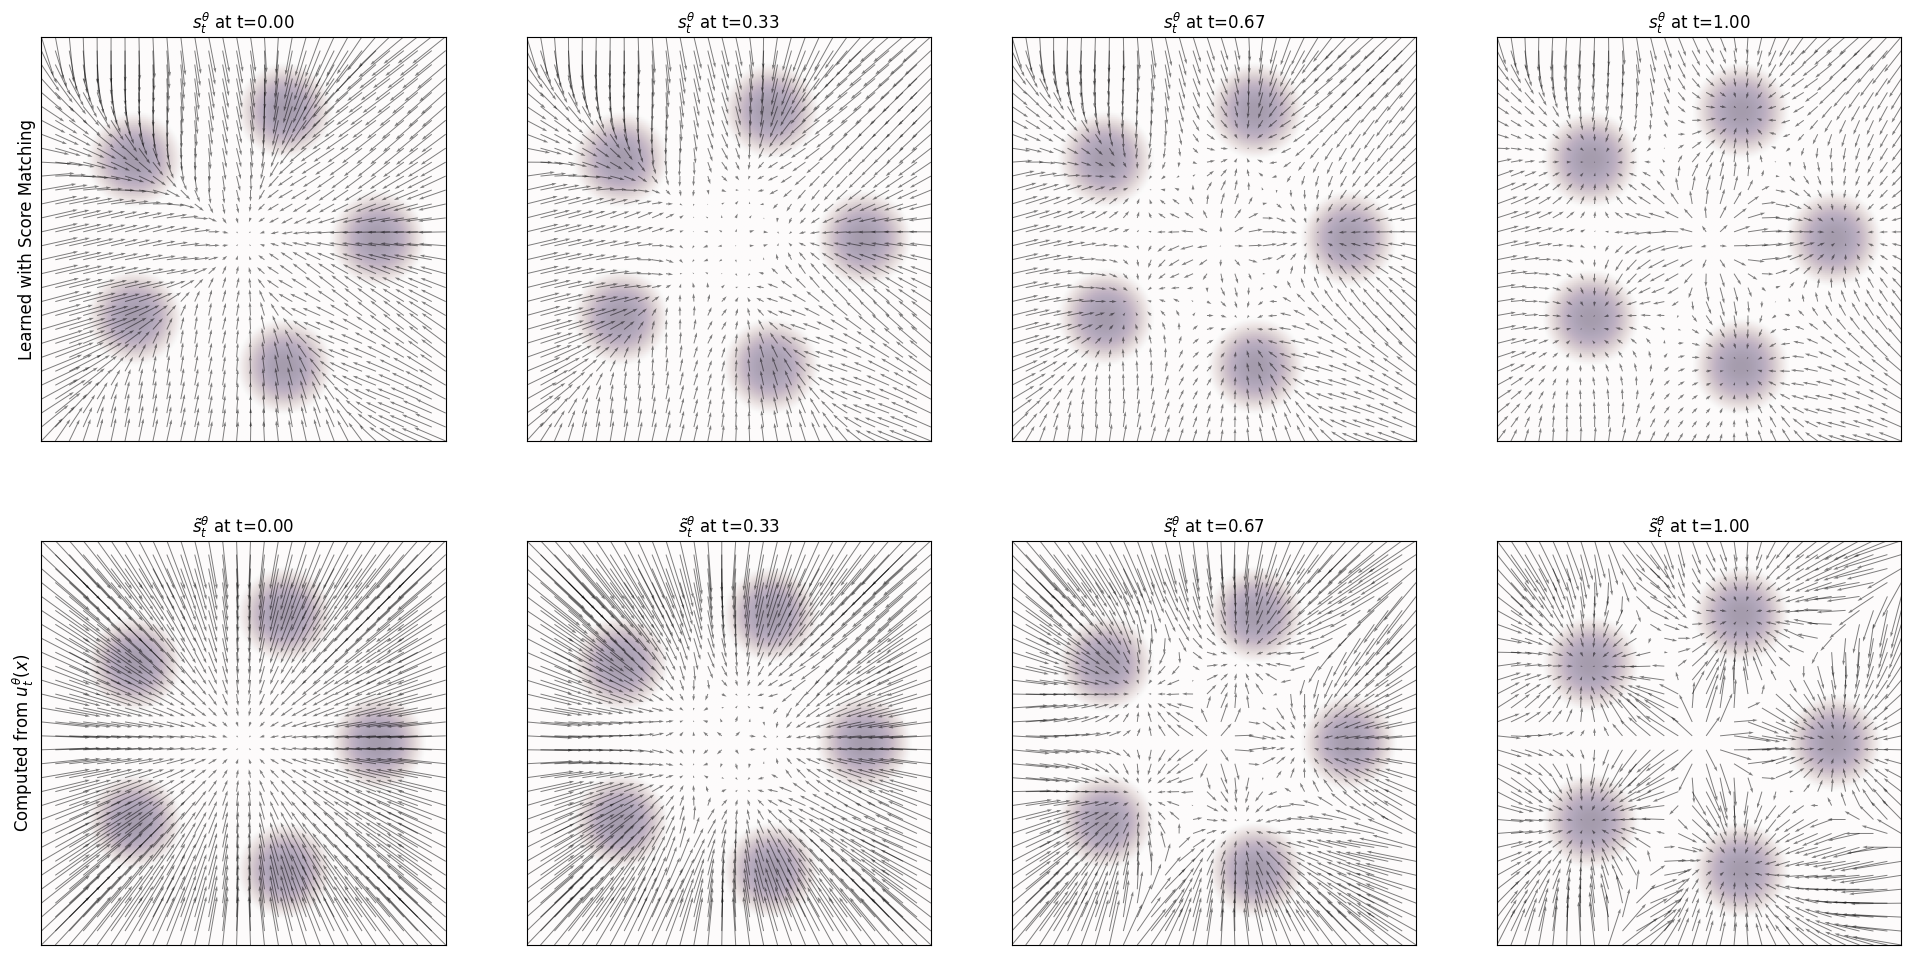

In [24]:
#######################
# Change these values #
#######################
num_bins = 30
num_marginals = 4

##############################
# Construct probability path #
##############################
path = GaussianConditionalProbabilityPath(
    p_data = GaussianMixture.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]).to(device), 
    alpha = LinearAlpha(),
    beta = SquareRootBeta()
).to(device)

#########################
# Define score networks #
#########################
learned_score_model = score_model
flow_score_model = ScoreFromVectorField(flow_model, path.alpha, path.beta)


###############################
# Plot score fields over time #
###############################
fig, axes = plt.subplots(2, num_marginals, figsize=(6 * num_marginals, 12))
axes = axes.reshape((2, num_marginals))

scale = PARAMS["scale"]
ts = torch.linspace(0.0, 0.9999, num_marginals).to(device)
xs = torch.linspace(-scale, scale, num_bins).to(device)
ys = torch.linspace(-scale, scale, num_bins).to(device)
xx, yy = torch.meshgrid(xs, ys)
xx = xx.reshape(-1,1)
yy = yy.reshape(-1,1)
xy = torch.cat([xx,yy], dim=-1)

axes[0,0].set_ylabel("Learned with Score Matching", fontsize=12)
axes[1,0].set_ylabel("Computed from $u_t^{{\\theta}}(x)$", fontsize=12)
for idx in range(num_marginals):
    t = ts[idx]
    bs = num_bins ** 2
    tt = t.view(1,1).expand(bs, 1)
    
    # Learned scores
    learned_scores = learned_score_model(xy, tt)
    learned_scores_x = learned_scores[:,0]
    learned_scores_y = learned_scores[:,1]

    ax = axes[0, idx]
    ax.quiver(xx.detach().cpu(), yy.detach().cpu(), learned_scores_x.detach().cpu(), learned_scores_y.detach().cpu(), scale=125, alpha=0.5)
    imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
    imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))
    ax.set_title(f'$s_{{t}}^{{\\theta}}$ at t={t.item():.2f}')
    ax.set_xticks([])
    ax.set_yticks([])
    

    # Flow score model
    ax = axes
    flow_scores = flow_score_model(xy,tt)
    flow_scores_x = flow_scores[:,0]
    flow_scores_y = flow_scores[:,1]

    ax = axes[1, idx]
    ax.quiver(xx.detach().cpu(), yy.detach().cpu(), flow_scores_x.detach().cpu(), flow_scores_y.detach().cpu(), scale=125, alpha=0.5)
    imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
    imshow_density(density=path.p_data, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=ax, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))
    ax.set_title(f'$\\tilde{{s}}_{{t}}^{{\\theta}}$ at t={t.item():.2f}')
    ax.set_xticks([])
    ax.set_yticks([])

# Parte 4: Flow Matching entre distribuições arbitrárias com caminho de probabilidade linear

Nessa seção, vamos considerar uma alternativa para o caminho de probabilidade condicional - o caminho linear de probabilidade condicional - que pode ser construído da seguinte forma:
Dada uma distribuição primária $p_{init}$ e a distribuição dos dados $p_{data}$, para um z fixo nós podemos considerar o interpolante:
$$ X_{t} = (1-t)X_{0} + tz $$
onde $X_{0} \sim p_{init}$ é uma variável aleatória. Podemos definir $p_{t}(x|z)$ para poder amostrar $X_{t}\sim p_{t}(x|z)$. Desse modo, $p_{0}(x|z) = p_{init}$ e $p_{t}(x|z) = \delta_{z}(x)$. Também é possível demonstrar que o campo condicional vetorial é dado por $u_{t}^{ref}(x) = \frac{z-x}{1-t}, \ para\ t\in [0,1]$. Fazemos então duas observações sobre o caminho linear de probabilidade condicional: Primeiro, diferentemente do caminho de probabilidade Gaussiana, nós não temos uma forma fechada para o score condicional $\nabla\ log\ p_{t}(x|z)$; Segundo, não há restrição para que $p_{init}$ seja gaussiana, o que vamos explorar no Problema 4.3 para contruir fluxos entre escolhas arbritárias de $p_{init}$ ou $p_{data}$. Como primeiro passo, examinemos algumas escolhas mais complexas para $p_{data}$.  

In [25]:
class MoonsSampleable(Sampleable):
    """
    Implementation of the Moons distribution using sklearn's make_moons
    """
    def __init__(self, device: torch.device, noise: float = 0.05, scale: float = 5.0, offset: Optional[torch.Tensor] = None):
        """
        Args:
            noise: Standard deviation of Gaussian noise added to the data
            scale: How much to scale the data
            offset: How much to shift the samples from the original distribution (2,)
        """
        self.noise = noise
        self.scale = scale
        self.device = device
        if offset is None:
            offset = torch.zeros(2)
        self.offset = offset.to(device)

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: Number of samples to generate
        Returns:
            torch.Tensor: Generated samples with shape (num_samples, 3)
        """
        samples, _ = make_moons(
            n_samples=num_samples,
            noise=self.noise,
            random_state=None  # Allow for random generation each time
        )
        return self.scale * torch.from_numpy(samples.astype(np.float32)).to(self.device) + self.offset

class CirclesSampleable(Sampleable):
    """
    Implementation of concentric circle distribution using sklearn's make_circles
    """
    def __init__(self, device: torch.device, noise: float = 0.05, scale=5.0, offset: Optional[torch.Tensor] = None):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.noise = noise
        self.scale = scale
        self.device = device
        if offset is None:
            offset = torch.zeros(2)
        self.offset = offset.to(device)

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        samples, _ = make_circles(
            n_samples=num_samples,
            noise=self.noise,
            factor=0.5,
            random_state=None
        )
        return self.scale * torch.from_numpy(samples.astype(np.float32)).to(self.device) + self.offset

class CheckerboardSampleable(Sampleable):
    """
    Checkboard-esque distribution
    """
    def __init__(self, device: torch.device, grid_size: int = 3, scale=5.0):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0,2).to(device)
        while samples.shape[0] < num_samples:
            # Sample num_samples
            new_samples = (torch.rand(num_samples,2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:,0] + self.scale) / grid_length) % 2 == 0 # (bs,)
            y_mask = torch.floor((new_samples[:,1] + self.scale) / grid_length) % 2 == 0 # (bs,)
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)
        return samples[:num_samples]

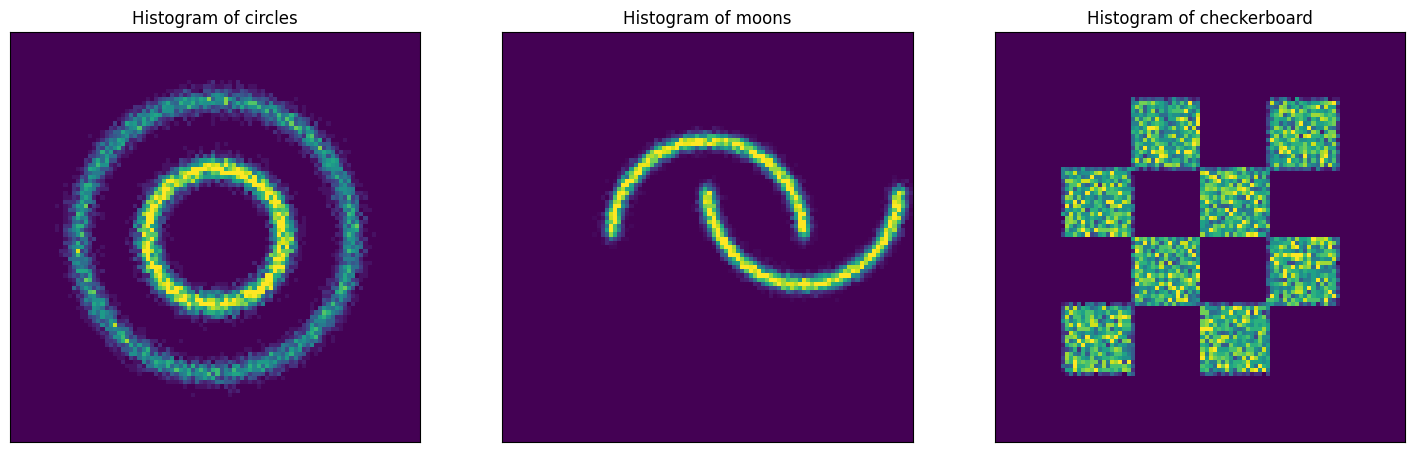

In [26]:
# Visualize alternative choices of p_data
targets = {
    "circles": CirclesSampleable(device),
    "moons": MoonsSampleable(device, scale=3.5),
    "checkerboard": CheckerboardSampleable(device, grid_size=4)
}

###################################
# Graph Various Choices of p_data #
###################################

fig, axes = plt.subplots(1, len(targets), figsize=(6 * len(targets), 6))

num_samples = 20000
num_bins = 100
for idx, (target_name, target) in enumerate(targets.items()):
    ax = axes[idx]
    hist2d_sampleable(target, num_samples, bins=num_bins, scale=7.5, ax=ax)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Histogram of {target_name}')

plt.show()